# 🏎️ Nina's F1 Predictions: 2026 Japanese Grand Prix (Round 3)
## Suzuka Circuit — March 27-29, 2026

**Model version:** v0.4 (Two-model approach + weather)  
**Data:** 72 races (2023-2026 complete), 1,442 entries + weather data  
**Last updated:** March 24, 2026

### What's New in v0.4
- **Two-model approach:** Separates "how fast is the car?" (2026 only) from "how good is the driver?" (all years). Solves the v0.3 problem where 2025 McLaren dominance bled into 2026 predictions.
- **Weather integration:** Air temp, track temp, humidity, rain probability. Historical wet-race performance per driver.
- **Smarter 2026 weighting:** Pre-2026 data only used for driver skill features, never for car performance.
- **Friendlier labels:** "10,000 simulated races" instead of "Monte Carlo simulation" — same math, clearer language.


In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from collections import defaultdict
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

# Load data
df = pd.read_csv('../data/all_results.csv')
weather = pd.read_csv('../data/weather.csv')
df['Position'] = pd.to_numeric(df['Position'], errors='coerce')
df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')
df['DNF'] = df['Status'].apply(lambda x: 0 if x == 'Finished' or (isinstance(x, str) and 'Lap' in x) else 1)
df = df.sort_values(['Year', 'Round']).reset_index(drop=True)

# Merge weather
df = df.merge(weather[['Year','Round','avg_air_temp','avg_track_temp','avg_humidity','avg_wind_speed','had_rain','rain_pct']], 
              on=['Year','Round'], how='left')

print(f"Loaded {len(df)} entries across {df[['Year','Round']].drop_duplicates().shape[0]} races")
print(f"Weather data: {len(weather)} races, {weather['had_rain'].sum()} wet")
print(f"\nBy year:")
for year, g in df.groupby('Year'):
    flag = '🟢' if year == 2026 else '🟡'
    print(f"  {flag} {year}: {g[['Round']].drop_duplicates().shape[0]} races")


Loaded 1442 entries across 72 races
Weather data: 72 races, 16 wet

By year:
  🟡 2023: 22 races
  🟡 2024: 24 races
  🟡 2025: 24 races
  🟢 2026: 2 races


## 1. The Two-Model Approach

The core insight: in a regulation-change year, **car performance** and **driver skill** need to be predicted separately.

### Model A: Car Pace (2026 only)
> "How fast is this car at this track?"

Trained ONLY on 2026 data. Uses constructor average finish, constructor qualifying pace, and team-level features. This ensures 2025 McLaren dominance doesn't leak into 2026 predictions where McLaren is struggling.

### Model B: Driver Skill (all years, 2026-weighted)
> "How much does this driver extract from their car?"

Uses all 72 races but measures driver performance RELATIVE to their car — teammate delta, positions gained, consistency, wet-weather ability. A driver who beats their teammate by 3 positions is skilled regardless of what year or car they're in.


## 2. Model A — Constructor Pace (2026 Only)


  🏗️ MODEL A: CAR PACE — 2026 Data Only (No Historical Bleed)

  Team                    Avg Finish   Avg Grid   Best  Tier
  -----------------------------------------------------------------
  Mercedes                P     1.5  P    1.5  P  1  Tier 1
  Ferrari                 P     3.5  P    4.5  P  3  Tier 2
  Haas F1 Team            P     9.2  P   12.0  P  5  Tier 3
  Alpine                  P    10.0  P   12.2  P  6  Tier 3
  Racing Bulls            P    10.0  P   11.5  P  7  Tier 3
  Red Bull Racing         P    12.5  P   10.0  P  6  Tier 4
  Williams                P    14.5  P   18.8  P  9  Tier 4
  Audi                    P    15.8  P   12.0  P  9  Tier 4
  Cadillac                P    15.8  P   19.2  P 13  Tier 4
  McLaren                 P    16.2  P    5.5  P  5  Tier 5
  Aston Martin            P    17.5  P   19.2  P 17  Tier 5


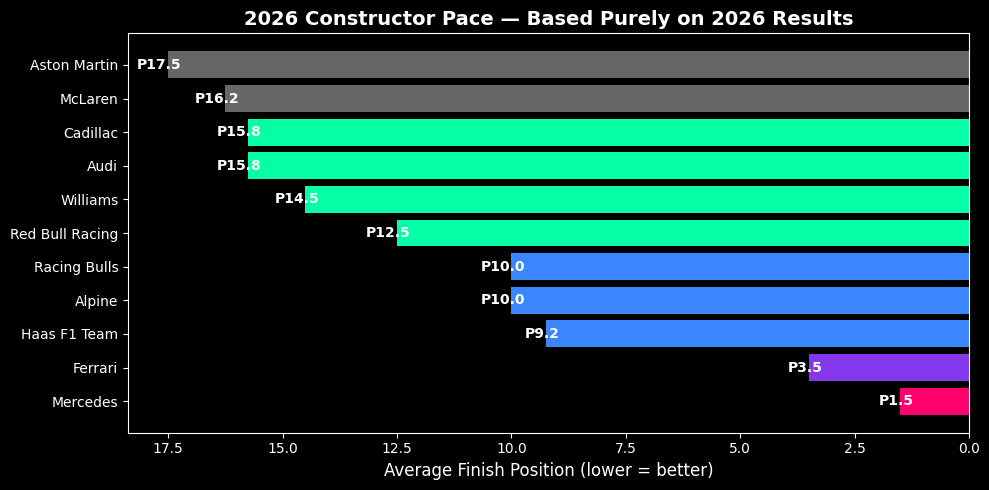

In [2]:
# Model A: Constructor strength from 2026 data ONLY
data_2026 = df[df['Year'] == 2026].copy()

constructor_pace = data_2026.groupby('TeamName').agg(
    avg_finish=('Position', 'mean'),
    avg_grid=('GridPosition', 'mean'),
    best_finish=('Position', 'min'),
    best_grid=('GridPosition', 'min'),
    entries=('Position', 'count')
).reset_index().sort_values('avg_finish')

# Tier assignment
def tier(avg):
    if avg <= 3: return ('Tier 1', '#ff006e')
    elif avg <= 7: return ('Tier 2', '#8338ec')
    elif avg <= 12: return ('Tier 3', '#3a86ff')
    elif avg <= 16: return ('Tier 4', '#06ffa5')
    else: return ('Tier 5', '#666666')

constructor_pace[['Tier', 'Color']] = constructor_pace['avg_finish'].apply(lambda x: pd.Series(tier(x)))
car_pace = dict(zip(constructor_pace['TeamName'], constructor_pace['avg_finish']))

print("=" * 70)
print("  🏗️ MODEL A: CAR PACE — 2026 Data Only (No Historical Bleed)")
print("=" * 70)
print(f"\n  {'Team':22s}  {'Avg Finish':>10s}  {'Avg Grid':>9s}  {'Best':>5s}  {'Tier'}")
print("  " + "-" * 65)
for _, row in constructor_pace.iterrows():
    print(f"  {row['TeamName']:22s}  P{row['avg_finish']:>8.1f}  P{row['avg_grid']:>7.1f}  P{row['best_finish']:>3.0f}  {row['Tier']}")

fig, ax = plt.subplots(figsize=(10, 5))
teams = constructor_pace.sort_values('avg_finish')
bars = ax.barh(teams['TeamName'], teams['avg_finish'], color=teams['Color'].values)
ax.set_xlabel('Average Finish Position (lower = better)', fontsize=12)
ax.set_title('2026 Constructor Pace — Based Purely on 2026 Results', fontsize=14, fontweight='bold')
ax.invert_xaxis()
for bar, val in zip(bars, teams['avg_finish']):
    ax.text(val - 0.3, bar.get_y() + bar.get_height()/2, f'P{val:.1f}', va='center', ha='right', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/constructor_pace_v4.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Model B — Driver Skill (All Years, Car-Independent)

Measures how good each driver is **relative to their equipment** — this transfers across regulation changes.


In [3]:
# Build driver skill features from ALL data
df = df.sort_values(['Year', 'Round']).reset_index(drop=True)
df['race_id'] = df['Year'].astype(str) + '_' + df['Round'].astype(str)
race_order = df[['race_id','Year','Round']].drop_duplicates().sort_values(['Year','Round']).reset_index(drop=True)
race_order['race_seq'] = range(len(race_order))
df = df.merge(race_order[['race_id','race_seq']], on='race_id', how='left')

features_list = []
for race_seq in sorted(df['race_seq'].unique()):
    race_data = df[df['race_seq'] == race_seq].copy()
    
    for _, row in race_data.iterrows():
        driver = row['FullName']
        team = row['TeamName']
        race_name = row['RaceName']
        
        hist = df[(df['FullName'] == driver) & (df['race_seq'] < race_seq)]
        hist_team = df[(df['TeamName'] == team) & (df['race_seq'] < race_seq)]
        
        last5 = hist.tail(5)
        last5_team = hist_team.tail(5)
        last10 = hist.tail(10)
        
        # Teammate delta (car-independent skill measure)
        teammate_hist = df[(df['TeamName'] == team) & (df['FullName'] != driver) & (df['race_seq'] < race_seq)]
        tm_deltas = []
        for seq in hist.tail(5)['race_seq'].values:
            my = hist[hist['race_seq'] == seq]['Position'].values
            tm = teammate_hist[teammate_hist['race_seq'] == seq]['Position'].values
            if len(my) > 0 and len(tm) > 0 and not np.isnan(my[0]) and not np.isnan(tm[0]):
                tm_deltas.append(tm[0] - my[0])
        
        # Wet weather skill (positions gained in wet races)
        wet_hist = hist[hist['had_rain'] == True]
        wet_gain = (wet_hist['GridPosition'] - wet_hist['Position']).mean() if len(wet_hist) > 0 else 0
        
        # Track experience
        track_hist = hist[hist['RaceName'] == race_name]
        
        features_list.append({
            'race_seq': race_seq, 'Year': row['Year'], 'Round': row['Round'],
            'RaceName': race_name, 'FullName': driver, 'TeamName': team,
            'grid_position': row['GridPosition'],
            'finish_position': row['Position'],
            # Car pace (2026 only — from Model A)
            'car_pace': car_pace.get(team, 15) if row['Year'] == 2026 else row.get('GridPosition', 12),
            # Driver skill features (all years — car-independent)
            'driver_avg_finish': last5['Position'].mean() if len(last5) > 0 else 12,
            'positions_gained_avg': (last5['GridPosition'] - last5['Position']).mean() if len(last5) > 0 else 0,
            'teammate_delta': np.mean(tm_deltas) if len(tm_deltas) > 0 else 0,
            'dnf_rate': last10['DNF'].mean() if len(last10) > 0 else 0.1,
            'consistency': last5['Position'].std() if len(last5) > 1 else 5,
            'track_experience': len(track_hist),
            'wet_skill': wet_gain,
            # Weather
            'air_temp': row.get('avg_air_temp', 22),
            'track_temp': row.get('avg_track_temp', 35),
            'humidity': row.get('avg_humidity', 50),
            'had_rain': 1 if row.get('had_rain', False) else 0,
            # Regulation flag
            'is_2026': 1 if row['Year'] == 2026 else 0,
            'DNF': row['DNF']
        })

feat_df = pd.DataFrame(features_list)
feat_df = feat_df.dropna(subset=['finish_position', 'grid_position'])

# Show driver skill rankings for 2026 grid
grid_2026 = data_2026['FullName'].unique()
latest_skills = []
for driver in grid_2026:
    d = feat_df[feat_df['FullName'] == driver].sort_values('race_seq')
    if len(d) > 0:
        latest = d.iloc[-1]
        latest_skills.append({
            'Driver': driver,
            'Team': latest['TeamName'],
            'Teammate_Delta': latest['teammate_delta'],
            'Pos_Gained': latest['positions_gained_avg'],
            'Consistency': latest['consistency'],
            'Wet_Skill': latest['wet_skill'],
        })

skill_df = pd.DataFrame(latest_skills).sort_values('Teammate_Delta', ascending=False)

print("=" * 75)
print("  👤 MODEL B: DRIVER SKILL — Car-Independent (All 72 Races)")
print("=" * 75)
print(f"\n  {'Driver':22s}  {'Team':18s}  {'vs Teammate':>12s}  {'Pos Gained':>10s}  {'Consistency':>11s}  {'Wet':>5s}")
print("  " + "-" * 82)
for _, row in skill_df.iterrows():
    tm = f"+{row['Teammate_Delta']:.1f}" if row['Teammate_Delta'] > 0 else f"{row['Teammate_Delta']:.1f}"
    pg = f"+{row['Pos_Gained']:.1f}" if row['Pos_Gained'] > 0 else f"{row['Pos_Gained']:.1f}"
    wet = f"+{row['Wet_Skill']:.1f}" if row['Wet_Skill'] > 0 else f"{row['Wet_Skill']:.1f}"
    print(f"  {row['Driver']:22s}  {row['Team']:18s}  {tm:>12s}  {pg:>10s}  ±{row['Consistency']:>9.1f}  {wet:>5s}")


  👤 MODEL B: DRIVER SKILL — Car-Independent (All 72 Races)

  Driver                  Team                 vs Teammate  Pos Gained  Consistency    Wet
  ----------------------------------------------------------------------------------
  Gabriel Bortoleto       Audi                       +13.0        +0.4  ±      4.5   -1.5
  Max Verstappen          Red Bull Racing            +12.2        +6.6  ±      2.2   +0.9
  Arvid Lindblad          Racing Bulls                +5.0        +1.0  ±      5.0    0.0
  Fernando Alonso         Aston Martin                +4.4        -1.4  ±      5.0   +0.1
  Lando Norris            McLaren                     +3.6        -4.0  ±      7.2   -1.9
  Carlos Sainz            Williams                    +3.4        +1.8  ±      5.4   -1.1
  Sergio Perez            Cadillac                    +3.0        -2.0  ±      4.2   +3.0
  Charles Leclerc         Ferrari                     +2.4        -1.4  ±      6.7   -3.1
  Pierre Gasly            Alpine            

## 4. XGBoost Model — Combining Car Pace + Driver Skill + Weather

The XGBoost model now uses features from both Model A (car pace) and Model B (driver skill), plus weather conditions. Crucially, `car_pace` for 2026 races comes ONLY from 2026 data.


  🤖 XGBOOST v0.4 — Two-Model + Weather

  Validation MAE: 2.40 positions
  Residual StdDev: 2.52
  Features: 14
  Training samples: 1218


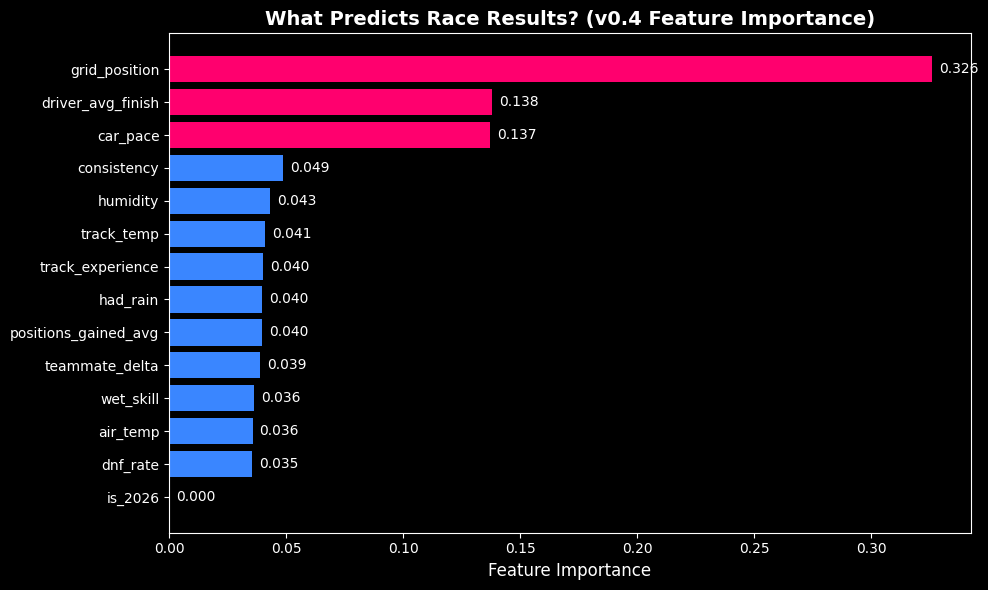

In [4]:
feature_cols = ['grid_position', 'car_pace', 'driver_avg_finish',
                'positions_gained_avg', 'teammate_delta', 'dnf_rate',
                'consistency', 'track_experience', 'wet_skill',
                'air_temp', 'track_temp', 'humidity', 'had_rain', 'is_2026']

train = feat_df[(feat_df['Year'] < 2026) & (feat_df['DNF'] == 0)].copy()
val = feat_df[(feat_df['Year'] == 2026) & (feat_df['DNF'] == 0)].copy()

X_train = train[feature_cols].fillna(0)
y_train = train['finish_position']
X_val = val[feature_cols].fillna(0)
y_val = val['finish_position']

model = XGBRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
model.fit(X_train, y_train)

val_pred = model.predict(X_val)
val_mae = mean_absolute_error(y_val, val_pred)
residual_std = np.std(y_val.values - val_pred)

print("=" * 60)
print("  🤖 XGBOOST v0.4 — Two-Model + Weather")
print("=" * 60)
print(f"\n  Validation MAE: {val_mae:.2f} positions")
print(f"  Residual StdDev: {residual_std:.2f}")
print(f"  Features: {len(feature_cols)}")
print(f"  Training samples: {len(X_train)}")

# Feature importance
importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff006e' if v > 0.12 else '#8338ec' if v > 0.06 else '#3a86ff' if v > 0.03 else '#06ffa5' for v in importance['Importance']]
ax.barh(importance['Feature'], importance['Importance'], color=colors)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('What Predicts Race Results? (v0.4 Feature Importance)', fontsize=14, fontweight='bold')
for i, (f, imp) in enumerate(zip(importance['Feature'], importance['Importance'])):
    ax.text(imp + 0.003, i, f'{imp:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/feature_importance_v4.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Japan GP Predictions

Combining Model A (car pace), Model B (driver skill), weather estimates, and XGBoost.

**Weather estimate for Suzuka (March):** ~18°C air, ~25°C track, moderate humidity, low rain probability (Suzuka 2025 was 14°C dry, 2024 was 22°C dry, 2023 was 27°C dry).


In [5]:
# Japan GP predictions
japan_preds = []
for driver in grid_2026:
    d_hist = feat_df[feat_df['FullName'] == driver].sort_values('race_seq')
    if len(d_hist) == 0:
        continue
    latest = d_hist.iloc[-1]
    team = latest['TeamName']
    
    # Suzuka experience
    suzuka_exp = len(d_hist[d_hist['RaceName'].str.contains('Japan', case=False, na=False)])
    
    # Build features
    features = {
        'grid_position': latest.get('grid_position', 12),
        'car_pace': car_pace.get(team, 15),  # 2026 ONLY
        'driver_avg_finish': latest['driver_avg_finish'],
        'positions_gained_avg': latest['positions_gained_avg'],
        'teammate_delta': latest['teammate_delta'],
        'dnf_rate': latest['dnf_rate'],
        'consistency': latest['consistency'],
        'track_experience': suzuka_exp,
        'wet_skill': latest['wet_skill'],
        'air_temp': 18.0,  # Suzuka March estimate
        'track_temp': 25.0,
        'humidity': 60.0,
        'had_rain': 0,  # Dry forecast
        'is_2026': 1
    }
    
    X = pd.DataFrame([features])[feature_cols].fillna(0)
    pred = model.predict(X)[0]
    
    japan_preds.append({
        'Driver': driver, 'Team': team,
        'Car_Pace': car_pace.get(team, 15),
        'Skill': latest['teammate_delta'],
        'Consistency': latest['consistency'],
        'Suzuka': suzuka_exp,
        'Predicted': pred,
        'Features': features
    })

japan_preds.sort(key=lambda x: x['Predicted'])
for i, p in enumerate(japan_preds):
    p['Rank'] = i + 1

print("=" * 85)
print("  🏁 PREDICTED FINISH — 2026 JAPANESE GP (v0.4: Two-Model + Weather)")
print("=" * 85)
print(f"\n  {'Pos':>3s}  {'Driver':22s}  {'Team':18s}  {'Car':>5s}  {'Skill':>6s}  {'±Cons':>6s}  {'Suzuka':>7s}  {'Pred':>6s}")
print("  " + "-" * 80)
for p in japan_preds:
    sk = f"+{p['Skill']:.1f}" if p['Skill'] > 0 else f"{p['Skill']:.1f}"
    sz = f"{p['Suzuka']}x" if p['Suzuka'] > 0 else "  new"
    print(f"  P{p['Rank']:>2d}  {p['Driver']:22s}  {p['Team']:18s}  P{p['Car_Pace']:>3.1f}  {sk:>6s}  ±{p['Consistency']:>4.1f}  {sz:>7s}  P{p['Predicted']:>4.1f}")


  🏁 PREDICTED FINISH — 2026 JAPANESE GP (v0.4: Two-Model + Weather)

  Pos  Driver                  Team                  Car   Skill   ±Cons   Suzuka    Pred
  --------------------------------------------------------------------------------
  P 1  Kimi Antonelli          Mercedes            P1.5    -1.8  ± 5.5       1x  P 2.3
  P 2  George Russell          Mercedes            P1.5    +1.8  ± 2.1       3x  P 2.6
  P 3  Charles Leclerc         Ferrari             P3.5    +2.4  ± 6.7       3x  P 4.2
  P 4  Max Verstappen          Red Bull Racing     P12.5   +12.2  ± 2.2       3x  P 4.7
  P 5  Lewis Hamilton          Ferrari             P3.5    -2.4  ± 5.3       3x  P 4.9
  P 6  Lando Norris            McLaren             P16.2    +3.6  ± 7.2       3x  P 6.3
  P 7  Oscar Piastri           McLaren             P16.2    -3.6  ± 9.7       3x  P 6.4
  P 8  Nico Hulkenberg         Audi                P15.8   -13.0  ± 7.0       3x  P 8.3
  P 9  Isack Hadjar            Red Bull Racing     P12.5  

## 6. What If It Rains?

Suzuka has been dry for the last 3 Japanese GPs, but March weather is unpredictable. Here's how predictions shift in wet conditions — drivers with strong wet-weather skills (positions gained in historical rain races) move up.


In [6]:
# Rain scenario
rain_preds = []
for p in japan_preds:
    features_wet = p['Features'].copy()
    features_wet['had_rain'] = 1
    features_wet['humidity'] = 85.0
    
    X_wet = pd.DataFrame([features_wet])[feature_cols].fillna(0)
    pred_wet = model.predict(X_wet)[0]
    
    rain_preds.append({
        'Driver': p['Driver'], 'Team': p['Team'],
        'Dry_Pos': p['Predicted'],
        'Wet_Pos': pred_wet,
        'Shift': p['Predicted'] - pred_wet,  # positive = better in rain
        'Wet_Skill': feat_df[feat_df['FullName'] == p['Driver']].iloc[-1]['wet_skill'] if len(feat_df[feat_df['FullName'] == p['Driver']]) > 0 else 0
    })

rain_df = pd.DataFrame(rain_preds).sort_values('Shift', ascending=False)

print("=" * 75)
print("  🌧️ RAIN SCENARIO — Who Gains, Who Loses?")
print("=" * 75)
print(f"\n  {'Driver':22s}  {'Team':18s}  {'Dry':>5s}  {'Wet':>5s}  {'Shift':>7s}  {'Rain Hist':>9s}")
print("  " + "-" * 70)
for _, row in rain_df.iterrows():
    shift = f"+{row['Shift']:.1f}" if row['Shift'] > 0 else f"{row['Shift']:.1f}"
    wet_sk = f"+{row['Wet_Skill']:.1f}" if row['Wet_Skill'] > 0 else f"{row['Wet_Skill']:.1f}"
    emoji = '🟢' if row['Shift'] > 0.5 else '🔴' if row['Shift'] < -0.5 else '⚪'
    print(f"  {emoji} {row['Driver']:22s}  {row['Team']:18s}  P{row['Dry_Pos']:>3.1f}  P{row['Wet_Pos']:>3.1f}  {shift:>7s}  {wet_sk:>9s}")


  🌧️ RAIN SCENARIO — Who Gains, Who Loses?

  Driver                  Team                  Dry    Wet    Shift  Rain Hist
  ----------------------------------------------------------------------
  🟢 Sergio Perez            Cadillac            P15.6  P13.9     +1.7       +3.0
  🟢 Valtteri Bottas         Cadillac            P14.1  P12.5     +1.6       +1.3
  🟢 Lance Stroll            Aston Martin        P15.8  P14.6     +1.3       +0.7
  🟢 Oliver Bearman          Haas F1 Team        P10.9  P9.8     +1.1       +2.7
  🟢 Gabriel Bortoleto       Audi                P13.7  P12.6     +1.1       -1.5
  🟢 Nico Hulkenberg         Audi                P8.3  P7.4     +0.9       +1.6
  🟢 Pierre Gasly            Alpine              P11.7  P11.0     +0.7       +3.0
  🟢 Esteban Ocon            Haas F1 Team        P13.4  P12.7     +0.7       +1.6
  🟢 Franco Colapinto        Alpine              P13.5  P12.9     +0.6       -1.6
  ⚪ Liam Lawson             Racing Bulls        P12.4  P12.0     +0.4       -0

## 7. Podium Probabilities (10,000 Simulated Races)

Each simulation adds calibrated randomness to the XGBoost predictions. The noise is based on the model's actual prediction error on 2026 races — not guessed.


  🎲 PODIUM PROBABILITIES (10,000 Simulated Races)

  Driver                  Team                   Win   Podium   Top 5   Top 10
  ------------------------------------------------------------------------
  Kimi Antonelli          Mercedes             35.3%    74.5%   92.3%    99.9%  █████████████████
  George Russell          Mercedes             30.4%    71.3%   90.3%    99.9%  ███████████████
  Charles Leclerc         Ferrari              12.1%    45.1%   73.9%    98.8%  ██████
  Max Verstappen          Red Bull Racing       8.4%    36.5%   65.9%    98.5%  ████
  Lewis Hamilton          Ferrari               7.6%    32.4%   63.0%    97.9%  ███
  Oscar Piastri           McLaren               2.6%    14.9%   38.7%    92.6%  █
  Lando Norris            McLaren               2.6%    16.2%   40.6%    93.7%  █
  Nico Hulkenberg         Audi                  0.5%     4.1%   14.7%    77.1%  
  Isack Hadjar            Red Bull Racing       0.4%     4.2%   14.7%    77.0%  
  Oliver Bearman   

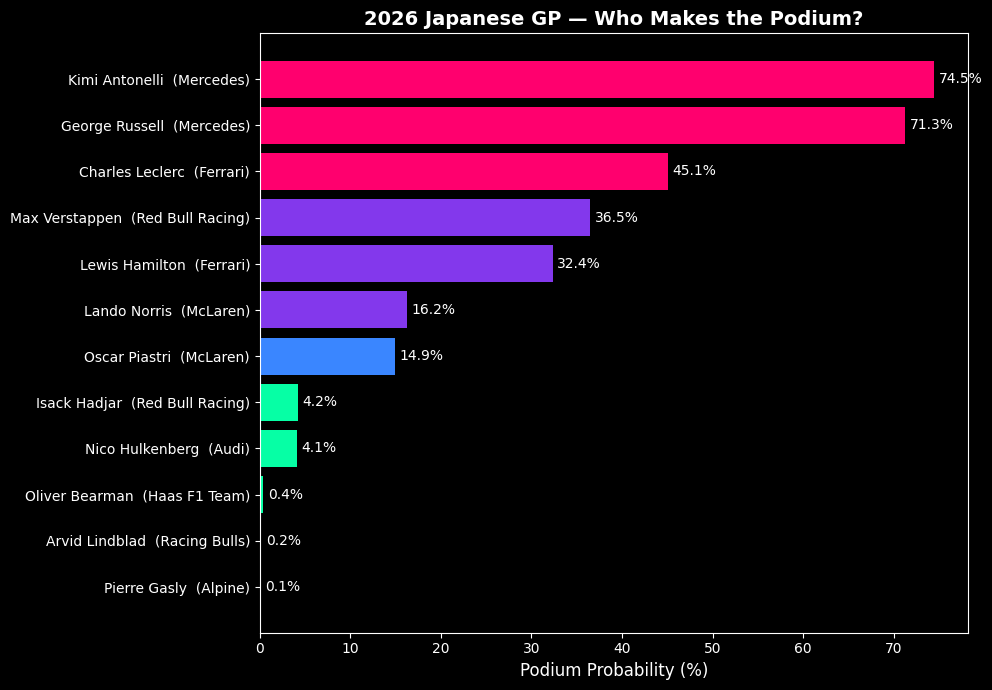

In [7]:
n_sims = 10000
position_totals = defaultdict(list)
podium_counts = defaultdict(int)
win_counts = defaultdict(int)
top5_counts = defaultdict(int)
top10_counts = defaultdict(int)

for _ in range(n_sims):
    sim = []
    for p in japan_preds:
        noise = np.random.normal(0, residual_std)
        sim.append((p['Driver'], p['Predicted'] + noise))
    sim.sort(key=lambda x: x[1])
    for pos, (driver, _) in enumerate(sim):
        position_totals[driver].append(pos + 1)
        if pos == 0: win_counts[driver] += 1
        if pos < 3: podium_counts[driver] += 1
        if pos < 5: top5_counts[driver] += 1
        if pos < 10: top10_counts[driver] += 1

prob_data = []
for p in japan_preds:
    d = p['Driver']
    prob_data.append({
        'Driver': d, 'Team': p['Team'], 'Rank': p['Rank'],
        'Win': win_counts[d]/n_sims*100, 'Podium': podium_counts[d]/n_sims*100,
        'Top5': top5_counts[d]/n_sims*100, 'Top10': top10_counts[d]/n_sims*100
    })

prob_df = pd.DataFrame(prob_data).sort_values('Win', ascending=False)

print("=" * 80)
print("  🎲 PODIUM PROBABILITIES (10,000 Simulated Races)")
print("=" * 80)
print(f"\n  {'Driver':22s}  {'Team':18s}  {'Win':>6s}  {'Podium':>7s}  {'Top 5':>6s}  {'Top 10':>7s}")
print("  " + "-" * 72)
for _, row in prob_df.head(15).iterrows():
    bar = '█' * int(row['Win'] / 2)
    print(f"  {row['Driver']:22s}  {row['Team']:18s}  {row['Win']:>5.1f}%  {row['Podium']:>6.1f}%  {row['Top5']:>5.1f}%  {row['Top10']:>6.1f}%  {bar}")

fig, ax = plt.subplots(figsize=(10, 7))
top12 = prob_df.head(12).sort_values('Podium')
colors = ['#ff006e' if p > 40 else '#8338ec' if p > 15 else '#3a86ff' if p > 5 else '#06ffa5' for p in top12['Podium']]
bars = ax.barh(top12['Driver'] + '  (' + top12['Team'] + ')', top12['Podium'], color=colors)
ax.set_xlabel('Podium Probability (%)', fontsize=12)
ax.set_title('2026 Japanese GP — Who Makes the Podium?', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top12['Podium']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/podium_v4.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Teammate Battles


In [8]:
teams_2026 = {}
for p in japan_preds:
    t = p['Team']
    if t not in teams_2026: teams_2026[t] = []
    teams_2026[t].append(p['Driver'])

print("=" * 60)
print("  🤝 TEAMMATE HEAD-TO-HEAD")
print("=" * 60)
print()
for team, drivers in sorted(teams_2026.items()):
    if len(drivers) >= 2:
        d1, d2 = drivers[0], drivers[1]
        d1w = sum(1 for i in range(n_sims) if position_totals[d1][i] < position_totals[d2][i])
        d1p, d2p = d1w/n_sims*100, 100-d1w/n_sims*100
        b1 = int(d1p/100*40)
        print(f"  {team}")
        print(f"  {d1:20s} {'█'*b1}{'░'*(40-b1)} {d2:>20s}")
        print(f"  {d1p:>19.1f}% {'':40s} {d2p:<.1f}%")
        print()


  🤝 TEAMMATE HEAD-TO-HEAD

  Alpine
  Pierre Gasly         ███████████████████████████░░░░░░░░░░░░░     Franco Colapinto
                 69.5%                                          30.5%

  Aston Martin
  Fernando Alonso      ████████████████████████░░░░░░░░░░░░░░░░         Lance Stroll
                 60.3%                                          39.7%

  Audi
  Nico Hulkenberg      █████████████████████████████████████░░░    Gabriel Bortoleto
                 93.2%                                          6.8%

  Cadillac
  Valtteri Bottas      ███████████████████████████░░░░░░░░░░░░░         Sergio Perez
                 67.7%                                          32.3%

  Ferrari
  Charles Leclerc      ███████████████████████░░░░░░░░░░░░░░░░░       Lewis Hamilton
                 58.6%                                          41.4%

  Haas F1 Team
  Oliver Bearman       ██████████████████████████████░░░░░░░░░░         Esteban Ocon
                 75.7%                    

## 9. F1 Fantasy Recommendations

Full scoring: Qualifying (P1=10...P10=1) + Race (P1=25...P10=1) + Positions gained + Overtakes + Fastest lap + DotD.  
Budget: $100M | 5 drivers + 2 constructors | 1 driver gets 2x boost.


In [9]:
race_pts = {1:25,2:18,3:15,4:12,5:10,6:8,7:6,8:4,9:2,10:1}
quali_pts = {1:10,2:9,3:8,4:7,5:6,6:5,7:4,8:3,9:2,10:1}
price_estimate = {
    'Mercedes':28,'Ferrari':25,'McLaren':22,'Red Bull Racing':20,
    'Aston Martin':12,'Alpine':10,'Racing Bulls':9,'Haas F1 Team':8,
    'Williams':8,'Audi':7,'Cadillac':6
}

fantasy = []
for p in japan_preds:
    d = p['Driver']
    exp_race = np.mean([race_pts.get(pos, 0) for pos in position_totals[d]])
    est_quali = max(1, min(22, int(p['Predicted'] * 0.9)))
    exp_quali = quali_pts.get(est_quali, 0)
    avg_sim = np.mean(position_totals[d])
    exp_gained = max(0, est_quali - avg_sim)
    total = exp_race + exp_quali + exp_gained * 1.5
    price = price_estimate.get(p['Team'], 10)
    value = total / price if price > 0 else 0
    fantasy.append({
        'Driver': d, 'Team': p['Team'], 'Rank': p['Rank'],
        'Race_Pts': exp_race, 'Quali_Pts': exp_quali, 'Bonus': exp_gained*1.5,
        'Total': total, 'Price': price, 'Value': value
    })

fantasy_df = pd.DataFrame(fantasy).sort_values('Total', ascending=False)

print("=" * 85)
print("  🏆 F1 FANTASY PICKS — Japan GP (v0.4)")
print("=" * 85)
print(f"\n  {'Driver':22s}  {'Team':16s}  {'Pred':>4s}  {'Race':>5s}  {'Qual':>5s}  {'Bonus':>5s}  {'TOTAL':>6s}  {'~$M':>4s}  {'Value':>5s}")
print("  " + "-" * 82)
for _, row in fantasy_df.iterrows():
    star = '⭐' if row['Value'] > 1.5 else '  '
    print(f"  {row['Driver']:22s}  {row['Team']:16s}  P{row['Rank']:>2.0f}  {row['Race_Pts']:>5.1f}  {row['Quali_Pts']:>5.0f}  {row['Bonus']:>5.1f}  {row['Total']:>5.1f}  ${row['Price']:>3.0f}  {row['Value']:>4.2f}  {star}")

print("\n  " + "=" * 55)
print("  💡 RECOMMENDED LINEUP")
print("  " + "=" * 55)
vp = fantasy_df.sort_values('Value', ascending=False)
print("\n  🔥 Best value (pts/$M):")
for _, r in vp.head(5).iterrows():
    print(f"     → {r['Driver']:22s} ({r['Team']:16s}) — {r['Total']:.1f} pts / ${r['Price']}M = {r['Value']:.2f}")
boost = fantasy_df.iloc[0]
print(f"\n  🚀 2x Boost: {boost['Driver']} ({boost['Team']}) — {boost['Total']:.1f} × 2 = {boost['Total']*2:.1f}")
print("\n  🏗️ Constructor picks:")
cf = fantasy_df.groupby('Team').agg(combined=('Total','sum'),price=('Price','first')).sort_values('combined',ascending=False)
for t, r in cf.head(3).iterrows():
    print(f"     → {t:22s} — {r['combined']:.1f} combined pts")


  🏆 F1 FANTASY PICKS — Japan GP (v0.4)

  Driver                  Team              Pred   Race   Qual  Bonus   TOTAL   ~$M  Value
  ----------------------------------------------------------------------------------
  Kimi Antonelli          Mercedes          P 1   17.9      9    0.0   26.9  $ 28  0.96    
  George Russell          Mercedes          P 2   17.2      9    0.0   26.2  $ 28  0.94    
  Charles Leclerc         Ferrari           P 3   13.1      8    0.0   21.1  $ 25  0.84    
  Max Verstappen          Red Bull Racing   P 4   11.8      7    0.0   18.8  $ 20  0.94    
  Lewis Hamilton          Ferrari           P 5   11.3      7    0.0   18.3  $ 25  0.73    
  Lando Norris            McLaren           P 6    8.2      6    0.0   14.2  $ 22  0.65    
  Oscar Piastri           McLaren           P 7    8.0      6    0.0   14.0  $ 22  0.63    
  Isack Hadjar            Red Bull Racing   P 9    4.4      4    0.0    8.4  $ 20  0.42    
  Nico Hulkenberg         Audi              P 8 

## 10. My Fantasy Teams — Analysis & Transfers


In [10]:
team1 = {
    'name': "Russellin' for Position",
    'drivers': [
        {'name': 'George Russell', 'price': 28.0, 'boost': True},
        {'name': 'Charles Leclerc', 'price': 23.4, 'boost': False},
        {'name': 'Kimi Antonelli', 'price': 23.8, 'boost': False},
        {'name': 'Oliver Bearman', 'price': 8.6, 'boost': False},
        {'name': 'Gabriel Bortoleto', 'price': 6.4, 'boost': False},
    ],
    'constructors': [{'name': 'Audi', 'price': 5.4}, {'name': 'Cadillac', 'price': 5.2}],
    'free_transfers': 3, 'cost_cap_remaining': 0.2
}

team2 = {
    'name': "Leclerc Me if You Can",
    'drivers': [
        {'name': 'Max Verstappen', 'price': 28.1, 'boost': True},
        {'name': 'Charles Leclerc', 'price': 23.4, 'boost': False},
        {'name': 'Kimi Antonelli', 'price': 23.8, 'boost': False},
        {'name': 'Franco Colapinto', 'price': 7.0, 'boost': False},
        {'name': 'Gabriel Bortoleto', 'price': 6.4, 'boost': False},
    ],
    'constructors': [{'name': 'Audi', 'price': 5.4}, {'name': 'Cadillac', 'price': 5.2}],
    'free_transfers': 3, 'cost_cap_remaining': 0.3
}

def analyze_team(team):
    print("=" * 75)
    print(f"  📋 {team['name'].upper()}")
    print(f"  Free Transfers: {team['free_transfers']} | Cap: ${team['cost_cap_remaining']}M")
    print("=" * 75)
    
    total = 0
    scores = []
    print(f"\n  {'Driver':22s}  {'$':>5s}  {'Boost':>5s}  {'Pred':>5s}  {'Pts':>6s}  {'Boosted':>8s}  {'Value':>5s}")
    print("  " + "-" * 65)
    
    for d in team['drivers']:
        row = fantasy_df[fantasy_df['Driver'] == d['name']]
        if len(row) > 0:
            r = row.iloc[0]
            pts, rank, val = r['Total'], int(r['Rank']), r['Value']
        else:
            pts, rank, val = 0, 22, 0
        boosted = pts * 2 if d['boost'] else pts
        total += boosted
        scores.append({'name': d['name'], 'price': d['price'], 'pts': pts, 'boosted': boosted, 'value': val, 'rank': rank, 'boost': d['boost']})
        bs = "2x ⚡" if d['boost'] else ""
        print(f"  {d['name']:22s}  ${d['price']:>4.1f}  {bs:>5s}  P{rank:>3d}  {pts:>5.1f}  {boosted:>7.1f}  {val:>4.2f}")
    
    c_total = 0
    print(f"\n  {'Constructor':22s}  {'$':>5s}  {'Combined Pts':>15s}")
    print("  " + "-" * 45)
    for c in team['constructors']:
        cp = fantasy_df[fantasy_df['Team'] == c['name']]['Total'].sum()
        c_total += cp
        print(f"  {c['name']:22s}  ${c['price']:>4.1f}  {cp:>14.1f}")
    
    grand = total + c_total
    print(f"\n  📊 PROJECTED TOTAL: {grand:.1f} pts (Drivers: {total:.1f} + Constructors: {c_total:.1f})")
    
    # Transfer recs
    cap = team['cost_cap_remaining']
    sorted_scores = sorted(scores, key=lambda x: x['value'])
    current_names = [d['name'] for d in team['drivers']]
    available = fantasy_df[~fantasy_df['Driver'].isin(current_names)].copy()
    
    print(f"\n  🔄 RECOMMENDED TRANSFERS:")
    moves = 0
    for weak in sorted_scores:
        if moves >= team['free_transfers']: break
        budget = weak['price'] + cap
        upgrades = available[available['Price'] <= budget].sort_values('Total', ascending=False)
        if len(upgrades) > 0:
            best = upgrades.iloc[0]
            gain = best['Total'] - weak['pts']
            if gain > 1:
                cost_diff = best['Price'] - weak['price']
                cap -= cost_diff
                moves += 1
                emoji = '🟢' if gain > 5 else '🟡'
                print(f"  {emoji} {weak['name']} → {best['Driver']} ({best['Team']})")
                print(f"     Points: {weak['pts']:.1f} → {best['Total']:.1f} (+{gain:.1f}) | Cost: {'+' if cost_diff>0 else ''}{cost_diff:.1f}M | Cap: ${cap:.1f}M")
                available = available[available['Driver'] != best['Driver']]
    
    # Boost check
    best_scorer = max(scores, key=lambda x: x['pts'])
    current_boost = [s for s in scores if s['boost']][0]
    if best_scorer['name'] != current_boost['name']:
        gain = best_scorer['pts'] - current_boost['pts']
        print(f"\n  ⚡ MOVE BOOST: {current_boost['name']} → {best_scorer['name']} (+{gain:.1f} pts)")
    else:
        print(f"\n  ✅ Boost correctly on {current_boost['name']}")
    
    return grand

print()
t1 = analyze_team(team1)
print()
t2 = analyze_team(team2)



  📋 RUSSELLIN' FOR POSITION
  Free Transfers: 3 | Cap: $0.2M

  Driver                      $  Boost   Pred     Pts   Boosted  Value
  -----------------------------------------------------------------
  George Russell          $28.0   2x ⚡  P  2   26.2     52.4  0.94
  Charles Leclerc         $23.4         P  3   21.1     21.1  0.84
  Kimi Antonelli          $23.8         P  1   26.9     26.9  0.96
  Oliver Bearman          $ 8.6         P 10    3.2      3.2  0.40
  Gabriel Bortoleto       $ 6.4         P 17    0.2      0.2  0.02

  Constructor                 $     Combined Pts
  ---------------------------------------------
  Audi                    $ 5.4             8.5
  Cadillac                $ 5.2             0.2

  📊 PROJECTED TOTAL: 112.5 pts (Drivers: 103.8 + Constructors: 8.7)

  🔄 RECOMMENDED TRANSFERS:
  🟢 Oliver Bearman → Nico Hulkenberg (Audi)
     Points: 3.2 → 8.4 (+5.2) | Cost: -1.6M | Cap: $1.8M

  ⚡ MOVE BOOST: George Russell → Kimi Antonelli (+0.7 pts)

  📋 LECLER

  Max Verstappen          $28.1   2x ⚡  P  4   18.8     37.6  0.94
  Charles Leclerc         $23.4         P  3   21.1     21.1  0.84
  Kimi Antonelli          $23.8         P  1   26.9     26.9  0.96
  Franco Colapinto        $ 7.0         P 16    0.2      0.2  0.02
  Gabriel Bortoleto       $ 6.4         P 17    0.2      0.2  0.02

  Constructor                 $     Combined Pts
  ---------------------------------------------
  Audi                    $ 5.4             8.5
  Cadillac                $ 5.2             0.2

  📊 PROJECTED TOTAL: 94.7 pts (Drivers: 86.0 + Constructors: 8.7)

  🔄 RECOMMENDED TRANSFERS:
  🟢 Franco Colapinto → Nico Hulkenberg (Audi)
     Points: 0.2 → 8.4 (+8.2) | Cost: 0.0M | Cap: $0.3M
  🟢 Max Verstappen → George Russell (Mercedes)
     Points: 18.8 → 26.2 (+7.4) | Cost: -0.1M | Cap: $0.4M

  ⚡ MOVE BOOST: Max Verstappen → Kimi Antonelli (+8.1 pts)


## 11. Summary & Confidence

### Confidence: MEDIUM
- **Two-model approach** solves the 2025-bleed problem — car pace comes purely from 2026 data
- **Weather integrated** — model trained on 72 races with weather, rain scenario available
- **72 races of training data** (full 2023-2025 + 2026 R1-R2)
- Still limited by 2 races of 2026 data for constructor pace

### What Gets Us to HIGH Confidence
- [ ] **Qualifying data (Saturday)** — the #1 predictor, re-run with actual grid
- [ ] **Practice pace (Friday)** — FP1/FP2 sector times for Suzuka-specific car pace
- [ ] **More 2026 races** — each race sharpens constructor tier predictions
- [ ] **Tire strategy data** — compound choices and degradation rates

### Model Version History
| Version | Approach | Key Improvement | Confidence |
|---------|----------|----------------|------------|
| v0.1 | ELO ratings | Baseline | LOW |
| v0.2 | Composite scoring | Regulation-aware, 2026-weighted | LOW-MEDIUM |
| v0.3 | XGBoost | ML-powered, feature importance | MEDIUM |
| **v0.4** | **Two-model + weather** | **Car vs driver separated, rain scenarios** | **MEDIUM** |
